# 06: Advanced SEM and ML Mediation Models

The previous notebooks built the discovery-quality mediation design, estimated a transparent linear g-computation decomposition, and stress-tested the result across definitions and specifications. This notebook adds a more advanced modeling layer.

The goal is to ask whether the same story survives with more flexible models and a more formal path-model framing. The goal is to ask whether the same story survives when we use more flexible models and a more formal path-model framing.

This notebook has four advanced pieces:

- **SEM-style path model**: estimate the `A -> M`, `M -> Y`, and `A -> Y` paths as a formal mediation path decomposition.
- **Cross-fitted ML nuisance models**: estimate mediator and outcome nuisance functions with Linear Regression, LightGBM, and XGBoost without evaluating each row on models trained on that row.
- **Heterogeneity analysis**: check whether the discovery effect differs across prior activity, prior satisfaction, prior discovery, and user activity groups.
- **Feature importance audit**: inspect which covariates the tree-based nuisance models use most.

The main question remains the same: does high discovery exposure increase future user value, and is that effect meaningfully routed through same-day satisfaction depth?

<!-- dataset-experiment-context -->
## Dataset and Mediation Design Context

This project uses KuaiRec interaction logs and metadata organized into active user-day records. The workflow constructs discovery-breadth, satisfaction-depth, quality-adjusted discovery, and shallow-click-pressure metrics from logged viewing behavior.

The data come from a real observational recommendation log. Discovery exposure, satisfaction depth, and future engagement arise from platform behavior, so the mediation analysis needs explicit identifying assumptions. The treatment is high discovery-breadth exposure, the mediator is same-day satisfaction depth, and the primary outcome is future seven-day interactions.

The project asks whether discovery exposure relates to future value directly, indirectly through satisfaction depth, or both. Because mediation in observational logs requires strong assumptions, the notebooks emphasize metric construction, temporal ordering, overlap, placebo-style checks, robustness across definitions, and model sensitivity.

**Role of this notebook.** This notebook compares SEM-style path models with cross-fitted machine-learning mediation workflows to assess model sensitivity.

<!-- mathematical-setup -->

## Mathematical Setup

The SEM-style part of this notebook uses path coefficients. A simple linear mediation system is

$$
M_i = \alpha_0 + \alpha_1 A_i + \alpha_X^\top X_i + u_i,
$$

$$
Y_i = \beta_0 + \beta_1 A_i + \beta_2 M_i + \beta_X^\top X_i + v_i.
$$

The product \(\alpha_1\beta_2\) is the linear indirect pathway, while \(\beta_1\) is the direct pathway. The ML part relaxes the linear form by using flexible nuisance models, then estimates counterfactual differences through cross-fitted predictions. The teaching point is to compare transparent path estimates with more flexible prediction-based mediation estimates.


#### 1. Load Libraries and Paths

This cell imports the modeling libraries used in the notebook. LightGBM and XGBoost are used for flexible nuisance models, while linear models provide the transparent baseline and SEM-style path estimates.

In [1]:
# Load libraries and paths.
from pathlib import Path
import os
import warnings

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "discovery_quality_mediation"


ANALYSIS_PANEL_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_analysis_panel.parquet"
EFFECT_SUMMARY_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_effect_summary.csv"
ROBUSTNESS_SUMMARY_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_robustness_summary.csv"

SEM_PATH_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_sem_path_results.csv"
SEM_BOOTSTRAP_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_sem_bootstrap.csv"
ML_EFFECTS_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_advanced_ml_effects.csv"
ML_PERFORMANCE_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_advanced_ml_performance.csv"
HETEROGENEITY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_advanced_heterogeneity.csv"
FEATURE_IMPORTANCE_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_advanced_feature_importance.csv"
ADVANCED_SUMMARY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_advanced_model_summary.csv"


The thread settings keep LightGBM and XGBoost from taking over the machine. The dataset is small enough that single-threaded tree models are still fast and easier to reproduce.

#### 2. Load Analysis Inputs

This cell loads the saved mediation analysis panel and the previous result tables. The advanced notebook should reuse the cleaned analysis object created earlier; it should reuse the cleaned analysis object created earlier.

In [2]:
analysis_panel = pd.read_parquet(ANALYSIS_PANEL_INPUT)
effect_summary = pd.read_csv(EFFECT_SUMMARY_INPUT)
robustness_summary = pd.read_csv(ROBUSTNESS_SUMMARY_INPUT)

load_summary = pd.DataFrame(
    {
        "artifact": ["analysis_panel", "effect_summary", "robustness_summary"],
        "rows": [len(analysis_panel), len(effect_summary), len(robustness_summary)],
        "columns": [analysis_panel.shape[1], effect_summary.shape[1], robustness_summary.shape[1]],
    }
)

main_effects = effect_summary.query(
    "outcome == 'Y_future_interactions' and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
)[["estimand", "estimate", "ci_95_lower", "ci_95_upper", "relative_effect"]]

display(load_summary)
display(main_effects.round(4))
display(robustness_summary.round(4))


,artifact,rows,columns
0,analysis_panel,8199,103
1,effect_summary,21,12
2,robustness_summary,4,9


,estimand,estimate,ci_95_lower,ci_95_upper,relative_effect
2,gcomp_total_effect,37.2781,32.2444,42.8135,0.1152
3,natural_direct_effect,38.5858,33.3634,43.7154,0.1192
4,natural_indirect_effect,-1.3077,-2.3047,-0.4290,-0.0036


,robustness_family,specifications,total_effect_min,total_effect_max,total_effect_share_positive,indirect_effect_min,indirect_effect_max,indirect_effect_share_positive,median_abs_indirect_to_total_ratio
0,threshold_sensitivity,4,37.2781,40.0555,1.0,-1.6532,-1.3077,0.0,0.0402
1,mediator_sensitivity,5,37.2560,37.3502,1.0,-1.7145,0.1281,0.2,0.0359
2,model_sensitivity,5,34.8085,37.6289,1.0,-1.5581,-0.9360,0.0,0.0351
3,outcome_sensitivity,1,37.2781,37.2781,1.0,-1.3077,-1.3077,0.0,0.0351


The earlier result is the benchmark. The advanced models should be judged against this reference because model flexibility alone is insufficient evidence of credibility. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


#### 3. Define Variables and Control Sets

This cell defines the treatment, mediator, outcome, and covariates. The covariates are the same pre-treatment history and profile features used in prior notebooks. This keeps the comparison focused on model form.

In [3]:
# Define variables and control sets.
TREATMENT = "A_high_discovery"
MEDIATOR = "M_satisfaction_depth"
PRIMARY_OUTCOME = "Y_future_interactions"
SECONDARY_OUTCOME = "Y_future_play_hours"
WEIGHT_COLUMN = "stabilized_ipw_capped"
GROUP_COLUMN = "user_id"
RANDOM_SEED = 42
N_SPLITS = 3
SEM_BOOTSTRAP_ITERATIONS = 100

base_numeric_covariates = [
    "calendar_day_index",
    "lag_1_active_day",
    "prior_3day_active_day",
    "lag_1_interactions",
    "prior_3day_interactions",
    "lag_1_total_play_duration_sec",
    "prior_3day_total_play_duration_sec",
    "lag_1_valid_play_share",
    "prior_3day_valid_play_share",
    "lag_1_high_satisfaction_share",
    "prior_3day_high_satisfaction_share",
    "lag_1_discovery_candidate_share",
    "prior_3day_discovery_candidate_share",
    "recent_activity_score",
    "register_days",
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "is_lowactive_period",
    "is_live_streamer",
    "is_video_author",
]
profile_onehot_covariates = [col for col in analysis_panel.columns if col.startswith("onehot_feat")]
numeric_covariates = [col for col in base_numeric_covariates + profile_onehot_covariates if col in analysis_panel.columns]
categorical_covariates = [
    col
    for col in [
        "user_active_degree",
        "follow_user_num_range",
        "fans_user_num_range",
        "friend_user_num_range",
        "register_days_range",
    ]
    if col in analysis_panel.columns
]

variable_summary = pd.DataFrame(
    {
        "item": ["treatment", "mediator", "primary_outcome", "secondary_outcome", "numeric_covariates", "categorical_covariates", "group_folds"],
        "value": [TREATMENT, MEDIATOR, PRIMARY_OUTCOME, SECONDARY_OUTCOME, len(numeric_covariates), len(categorical_covariates), N_SPLITS],
    }
)

display(variable_summary)


,item,value
0,treatment,A_high_discovery
1,mediator,M_satisfaction_depth
2,primary_outcome,Y_future_interactions
3,secondary_outcome,Y_future_play_hours
4,numeric_covariates,39
5,categorical_covariates,5
6,group_folds,3


The cross-fitting group is `user_id`, so the same user's days are kept out of both train and validation folds. That is important because each user contributes repeated active days.

#### 4. Build the Modeling Matrix

This cell prepares the adjustment matrix used by the SEM and ML models. Numeric columns are median-filled, categorical columns are one-hot encoded, and constant columns are removed.

In [4]:
# Build the modeling matrix.
def make_safe_column_names(columns):
    """
    Create formula-safe column names for SEM-style modeling.
    
    Idea
    ----
    The helper removes characters that can confuse formula parsers while preserving a mapping back to readable covariate names.
    
    Parameters
    ----------
    columns : object
        Column names to clean or preserve.
    
    Returns
    -------
    tuple[list[str], dict[str, str]]
        Safe column names and mapping from original names to safe names.
    """
    safe_names = []
    counts = {}
    for col in columns:
        safe = "".join(ch if ch.isalnum() else "_" for ch in str(col))
        safe = "_".join(part for part in safe.split("_") if part)
        if not safe:
            safe = "feature"
        if safe[0].isdigit():
            safe = f"feature_{safe}"
        counts[safe] = counts.get(safe, 0) + 1
        if counts[safe] > 1:
            safe = f"{safe}_{counts[safe]}"
        safe_names.append(safe)
    return safe_names


def build_covariate_matrix(frame, numeric_cols, categorical_cols):
    """
    Build a numeric covariate matrix for mediation adjustment.
    
    Idea
    ----
    The helper combines numeric and categorical pre-treatment covariates into a model matrix used by treatment, mediator, and outcome models.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    numeric_cols : object
        Numeric covariate columns used by the model.
    categorical_cols : object
        Categorical covariate columns used by the model.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix aligned with the input frame.
    """
    numeric = frame[numeric_cols].copy()
    for col in numeric.columns:
        numeric[col] = pd.to_numeric(numeric[col], errors="coerce")
        numeric[col] = numeric[col].fillna(numeric[col].median())

    if categorical_cols:
        categorical = frame[categorical_cols].copy()
        for col in categorical.columns:
            categorical[col] = categorical[col].astype("string").fillna("missing")
        encoded = pd.get_dummies(categorical, drop_first=True, dtype=float)
        design = pd.concat([numeric, encoded], axis=1)
    else:
        design = numeric

    design = design.loc[:, design.nunique(dropna=False) > 1]
    design.columns = make_safe_column_names(design.columns)
    return design.astype(float)

X_covariates = build_covariate_matrix(analysis_panel, numeric_covariates, categorical_covariates)
A = analysis_panel[TREATMENT].astype(float).to_numpy()
M = analysis_panel[MEDIATOR].astype(float).to_numpy()
Y = analysis_panel[PRIMARY_OUTCOME].astype(float).to_numpy()
weights = analysis_panel[WEIGHT_COLUMN].astype(float).to_numpy()
groups = analysis_panel[GROUP_COLUMN].to_numpy()

matrix_summary = pd.DataFrame(
    {
        "item": ["rows", "covariate_columns", "treatment_rate", "mediator_mean", "outcome_mean", "unique_users"],
        "value": [len(analysis_panel), X_covariates.shape[1], A.mean(), M.mean(), Y.mean(), analysis_panel[GROUP_COLUMN].nunique()],
    }
)

display(matrix_summary)
display(X_covariates.head())


,item,value
0,rows,8199.000000
1,covariate_columns,54.000000
2,treatment_rate,0.500061
3,mediator_mean,0.618626
4,outcome_mean,340.694475
5,unique_users,133.000000


,calendar_day_index,lag_1_active_day,prior_3day_active_day,lag_1_interactions,prior_3day_interactions,lag_1_total_play_duration_sec,prior_3day_total_play_duration_sec,lag_1_valid_play_share,prior_3day_valid_play_share,lag_1_high_satisfaction_share,prior_3day_high_satisfaction_share,lag_1_discovery_candidate_share,prior_3day_discovery_candidate_share,recent_activity_score,register_days,follow_user_num,fans_user_num,friend_user_num,is_video_author,onehot_feat0,onehot_feat1,onehot_feat2,onehot_feat3,onehot_feat4,onehot_feat6,onehot_feat7,onehot_feat8,onehot_feat9,onehot_feat10,onehot_feat11,onehot_feat12,onehot_feat13,onehot_feat14,onehot_feat15,onehot_feat17,user_active_degree_full_active,user_active_degree_high_active,follow_user_num_range_10_50,follow_user_num_range_100_150,follow_user_num_range_150_250,follow_user_num_range_250_500,follow_user_num_range_50_100,follow_user_num_range_0,follow_user_num_range_500,fans_user_num_range_1_10,fans_user_num_range_10_100,friend_user_num_range_1_5,friend_user_num_range_30_60,friend_user_num_range_5_30,register_days_range_31_60,register_days_range_366_730,register_days_range_61_90,register_days_range_730,register_days_range_91_180
0,0.0,0.0,0.0,0.0,0.0,0.000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,224.0,7.0,3.0,0.0,0.0,0.0,1.0,24.0,876.0,1.0,1.0,4.0,98.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,1.0,1.0,32.0,32.0,163.970,163.970,0.937500,0.937500,0.156250,0.156250,0.687500,0.687500,0.562990,224.0,7.0,3.0,0.0,0.0,0.0,1.0,24.0,876.0,1.0,1.0,4.0,98.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,1.0,2.0,20.0,52.0,130.986,294.956,0.950000,1.887500,0.350000,0.506250,0.450000,1.137500,0.639277,224.0,7.0,3.0,0.0,0.0,0.0,1.0,24.0,876.0,1.0,1.0,4.0,98.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,1.0,3.0,16.0,68.0,100.920,395.876,1.000000,2.887500,0.187500,0.693750,0.437500,1.575000,0.681755,224.0,7.0,3.0,0.0,0.0,0.0,1.0,24.0,876.0,1.0,1.0,4.0,98.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.0,1.0,3.0,37.0,73.0,222.720,454.626,0.891892,2.841892,0.216216,0.753716,0.432432,1.319932,0.693019,224.0,7.0,3.0,0.0,0.0,0.0,1.0,24.0,876.0,1.0,1.0,4.0,98.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The modeling matrix is intentionally reused across methods. SEM, Linear Regression, LightGBM, and XGBoost all see the same observed adjustment information. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


## Advanced Mediation Workflow

### SEM-Style Path Model

This cell estimates a simple path model:

- `M = alpha * A + X + error`
- `Y = c_prime * A + beta * M + X + error`
- `indirect = alpha * beta`
- `total_path = c_prime + alpha * beta`

This is a transparent path-analysis version of the mediation story. It is a transparent path-analysis version of the mediation story, which is often enough for product analytics settings where the variables are observed scores.

In [5]:
# SEM-Style path model.
def design_with_columns(covariates, **named_arrays):
    """
    Create a design matrix with a fixed column order.
    
    Idea
    ----
    The helper keeps SEM-style and machine-learning models aligned when training and prediction frames are built separately.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix with the requested columns in a stable order.
    """
    design = covariates.copy()
    for name, values in reversed(list(named_arrays.items())):
        design.insert(0, name, np.asarray(values, dtype=float))
    return design


def fit_sem_path(frame, covariates):
    """
    Fit the SEM-style mediation path model.
    
    Idea
    ----
    The function estimates treatment-to-mediator, treatment-to-outcome, and mediator-to-outcome paths in a compact linear system for comparison with g-computation.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    covariates : object
        Project-specific input named `covariates` used by this helper.
    
    Returns
    -------
    dict
        Path coefficients and implied direct, indirect, and total effects.
    """
    a = frame[TREATMENT].astype(float).to_numpy()
    m = frame[MEDIATOR].astype(float).to_numpy()
    y = frame[PRIMARY_OUTCOME].astype(float).to_numpy()
    w = frame[WEIGHT_COLUMN].astype(float).to_numpy()

    mediator_design = design_with_columns(covariates, A=a)
    mediator_model = LinearRegression().fit(mediator_design, m, sample_weight=w)
    alpha = float(mediator_model.coef_[0])

    outcome_design = design_with_columns(covariates, A=a, M=m)
    outcome_model = LinearRegression().fit(outcome_design, y, sample_weight=w)
    c_prime = float(outcome_model.coef_[0])
    beta = float(outcome_model.coef_[1])

    total_design = design_with_columns(covariates, A=a)
    total_model = LinearRegression().fit(total_design, y, sample_weight=w)
    total_coefficient = float(total_model.coef_[0])

    return {
        "alpha_A_to_M": alpha,
        "beta_M_to_Y": beta,
        "c_prime_A_to_Y": c_prime,
        "indirect_alpha_beta": alpha * beta,
        "total_path_c_prime_plus_indirect": c_prime + alpha * beta,
        "total_regression_coefficient": total_coefficient,
        "mediator_model_r2": mediator_model.score(mediator_design, m, sample_weight=w),
        "outcome_model_r2": outcome_model.score(outcome_design, y, sample_weight=w),
        "total_model_r2": total_model.score(total_design, y, sample_weight=w),
    }

sem_path_results = pd.DataFrame([fit_sem_path(analysis_panel, X_covariates)])

display(sem_path_results.round(4))


,alpha_A_to_M,beta_M_to_Y,c_prime_A_to_Y,indirect_alpha_beta,total_path_c_prime_plus_indirect,total_regression_coefficient,mediator_model_r2,outcome_model_r2,total_model_r2
0,0.0231,-48.4626,38.4311,-1.1172,37.3139,37.3139,0.4653,0.6642,0.6637


The SEM-style table gives a compact path decomposition. If `alpha` is positive while `beta` is negative, high discovery can increase satisfaction depth while another pathway carries future interaction gains.

### Bootstrap the SEM-Style Paths by User

This cell bootstraps the path model by resampling users. The purpose is to quantify how stable the SEM-style path coefficients are under the repeated-user structure.

In [6]:
# Bootstrap the SEM-Style paths by user.
rng = np.random.default_rng(RANDOM_SEED)
unique_users = np.sort(analysis_panel[GROUP_COLUMN].unique())
indexed_panel = analysis_panel.set_index(GROUP_COLUMN, drop=False)
sem_bootstrap_rows = []

for iteration in range(SEM_BOOTSTRAP_ITERATIONS):
    sampled_users = rng.choice(unique_users, size=len(unique_users), replace=True)
    sample = indexed_panel.loc[sampled_users].reset_index(drop=True)
    sample_covariates = build_covariate_matrix(sample, numeric_covariates, categorical_covariates)
    sample_covariates = sample_covariates.reindex(columns=X_covariates.columns, fill_value=0.0)
    row = fit_sem_path(sample, sample_covariates)
    row["bootstrap_iteration"] = iteration
    sem_bootstrap_rows.append(row)

sem_bootstrap = pd.DataFrame(sem_bootstrap_rows)
sem_interval_rows = []
for column in [
    "alpha_A_to_M",
    "beta_M_to_Y",
    "c_prime_A_to_Y",
    "indirect_alpha_beta",
    "total_path_c_prime_plus_indirect",
    "total_regression_coefficient",
]:
    sem_interval_rows.append(
        {
            "path_quantity": column,
            "estimate": sem_path_results.loc[0, column],
            "bootstrap_mean": sem_bootstrap[column].mean(),
            "ci_95_lower": sem_bootstrap[column].quantile(0.025),
            "ci_95_upper": sem_bootstrap[column].quantile(0.975),
        }
    )

sem_path_summary = pd.DataFrame(sem_interval_rows)

display(sem_path_summary.round(4))


,path_quantity,estimate,bootstrap_mean,ci_95_lower,ci_95_upper
0,alpha_A_to_M,0.0231,0.0235,0.0183,0.0281
1,beta_M_to_Y,-48.4626,-48.4765,-74.0799,-21.9557
2,c_prime_A_to_Y,38.4311,38.7951,32.6143,44.0143
3,indirect_alpha_beta,-1.1172,-1.1509,-1.8332,-0.4317
4,total_path_c_prime_plus_indirect,37.3139,37.6442,31.4660,42.8712
5,total_regression_coefficient,37.3139,37.6442,31.4660,42.8712


The bootstrapped path table is the formal counterpart to the earlier g-computation results. It lets us compare whether the simple path-product indirect effect points in the same direction as the notebook 04 indirect estimate.

#### 7. Plot SEM Path Quantities

This cell plots the SEM-style path quantities with bootstrap intervals. The visual focuses on the direct path, indirect path, and total path because these are the quantities that correspond most closely to the earlier decomposition.

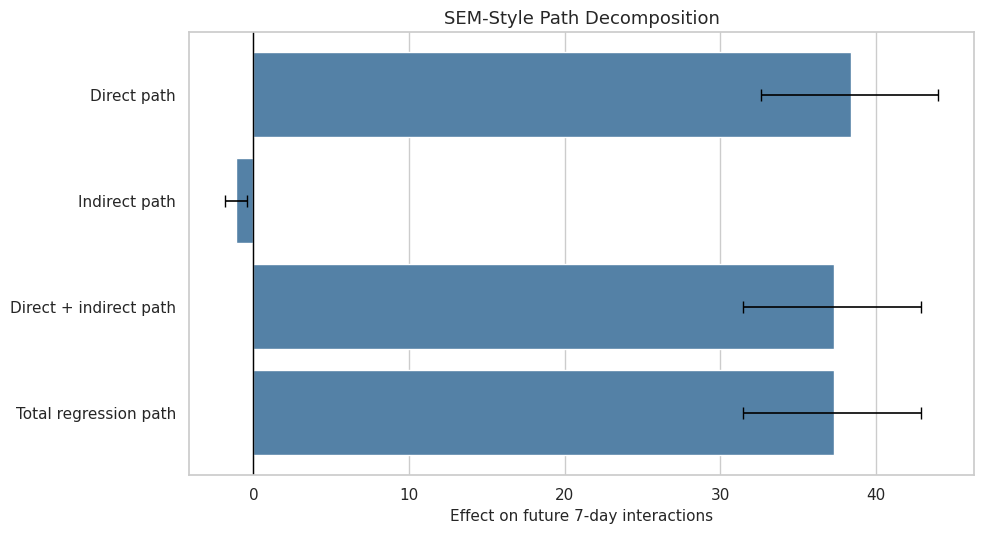

In [7]:
# Plot SEM path quantities.
sem_plot = sem_path_summary.query(
    "path_quantity in ['c_prime_A_to_Y', 'indirect_alpha_beta', 'total_path_c_prime_plus_indirect', 'total_regression_coefficient']"
).copy()
sem_plot["label"] = sem_plot["path_quantity"].map(
    {
        "c_prime_A_to_Y": "Direct path",
        "indirect_alpha_beta": "Indirect path",
        "total_path_c_prime_plus_indirect": "Direct + indirect path",
        "total_regression_coefficient": "Total regression path",
    }
)
sem_plot["lower_error"] = sem_plot["estimate"] - sem_plot["ci_95_lower"]
sem_plot["upper_error"] = sem_plot["ci_95_upper"] - sem_plot["estimate"]

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=sem_plot, x="estimate", y="label", color="steelblue", ax=ax)
for row_index, row in sem_plot.reset_index(drop=True).iterrows():
    ax.errorbar(
        x=row["estimate"],
        y=row_index,
        xerr=[[row["lower_error"]], [row["upper_error"]]],
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.2,
    )
ax.axvline(0, color="black", linewidth=1)
ax.set_title("SEM-Style Path Decomposition")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


The SEM plot summarizes the existing path-model assumptions and coefficients. It is useful because it compresses the mediation story into a few path coefficients.

### Define Cross-Fitted ML Nuisance Models

This cell defines the model families used in the cross-fitted g-computation. The Linear model is the transparent baseline. LightGBM and XGBoost allow nonlinearities and interactions in the nuisance functions.

In [8]:
# Define cross-fitted ML nuisance models.
model_factories = {
    "linear": lambda: LinearRegression(),
    "lightgbm": lambda: LGBMRegressor(
        n_estimators=80,
        learning_rate=0.05,
        num_leaves=24,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        n_jobs=1,
        verbose=-1,
    ),
    "xgboost": lambda: XGBRegressor(
        n_estimators=80,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=1,
        verbosity=0,
    ),
}

model_summary = pd.DataFrame(
    {
        "model_family": list(model_factories.keys()),
        "role": [
            "transparent benchmark",
            "tree-based nonlinear nuisance model",
            "boosted-tree nonlinear nuisance model",
        ],
    }
)

display(model_summary)


,model_family,role
0,linear,transparent benchmark
1,lightgbm,tree-based nonlinear nuisance model
2,xgboost,boosted-tree nonlinear nuisance model


All three model families estimate the same counterfactual quantities. That keeps the comparison fair because nuisance flexibility changes while the causal estimand stays fixed. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


#### 9. Implement Cross-Fitted ML G-Computation

This cell implements group cross-fitting. For each fold, models are trained on some users and evaluated on held-out users. The estimator predicts `M(0)`, `M(1)`, `Y(0, M(0))`, `Y(1, M(0))`, and `Y(1, M(1))` out of fold, then averages the implied effects.

In [9]:
# Implement cross-fitted ML g-computation.
def treatment_design(covariates, treatment_values):
    """
    Create a design matrix for treatment or mediator models.
    
    Idea
    ----
    The helper appends treatment values to the covariate matrix so counterfactual mediator or outcome predictions can be generated.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    treatment_values : object
        Counterfactual or observed treatment values to place in the design matrix.
    
    Returns
    -------
    pandas.DataFrame
        Design matrix containing covariates and treatment values.
    """
    design = covariates.copy()
    design.insert(0, TREATMENT, np.asarray(treatment_values, dtype=float))
    return design


def outcome_design(covariates, treatment_values, mediator_values):
    """
    Create a design matrix for mediation outcome models.
    
    Idea
    ----
    The helper combines covariates, treatment values, and mediator values so direct and indirect pathways can be predicted under counterfactual settings.
    
    Parameters
    ----------
    covariates : object
        Project-specific input named `covariates` used by this helper.
    treatment_values : object
        Counterfactual or observed treatment values to place in the design matrix.
    mediator_values : object
        Mediator values to place in the outcome design matrix.
    
    Returns
    -------
    pandas.DataFrame
        Outcome-model design matrix.
    """
    treatment_array = np.asarray(treatment_values, dtype=float)
    mediator_array = np.asarray(mediator_values, dtype=float)
    design = covariates.copy()
    design.insert(0, "A_x_M", treatment_array * mediator_array)
    design.insert(0, MEDIATOR, mediator_array)
    design.insert(0, TREATMENT, treatment_array)
    return design


def fit_with_optional_weight(model, X, y, sample_weight=None):
    """
    Fit a model with sample weights when supported.
    
    Idea
    ----
    The helper lets the mediation workflow use the same call pattern for weighted and unweighted model families.
    
    Parameters
    ----------
    model : object
        Fitted or unfitted model used in the helper.
    X : object
        Feature matrix.
    y : object
        Target vector.
    sample_weight : object
        Optional observation weights for model fitting.
    
    Returns
    -------
    sklearn estimator
        Fitted model instance.
    """
    try:
        model.fit(X, y, sample_weight=sample_weight)
    except TypeError:
        model.fit(X, y)
    return model


def regression_metrics(y_true, y_pred):
    """
    Compute regression diagnostics for nuisance predictions.
    
    Idea
    ----
    The helper summarizes predictive performance so ML mediation estimates can be judged alongside nuisance-model quality.
    
    Parameters
    ----------
    y_true : object
        Observed target values.
    y_pred : object
        Predicted target values.
    
    Returns
    -------
    dict
        Regression metrics such as RMSE, MAE, and R-squared.
    """
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return {
        "rmse": rmse,
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }


def crossfit_ml_mediation(model_name, model_factory, outcome_col=PRIMARY_OUTCOME):
    """
    Run cross-fitted machine-learning mediation for one outcome.
    
    Idea
    ----
    The function fits mediator and outcome nuisance models out of fold, predicts counterfactual pathways, and summarizes how ML-based effects compare with linear mediation.
    
    Parameters
    ----------
    model_name : object
        Label identifying the model family or specification.
    model_factory : object
        Callable that creates a fresh model for each fold.
    outcome_col : object
        Outcome column used in the estimator.
    
    Returns
    -------
    pandas.DataFrame
        Cross-fitted mediation effect estimates and nuisance-model diagnostics.
    """
    n = len(analysis_panel)
    splitter = GroupKFold(n_splits=N_SPLITS)

    m_hat = np.zeros(n)
    y_hat = np.zeros(n)
    m0 = np.zeros(n)
    m1 = np.zeros(n)
    y_0_m0 = np.zeros(n)
    y_1_m0 = np.zeros(n)
    y_1_m1 = np.zeros(n)
    y_0_m1 = np.zeros(n)

    fold_rows = []
    for fold_id, (train_idx, test_idx) in enumerate(splitter.split(X_covariates, A, groups=groups), start=1):
        X_train = X_covariates.iloc[train_idx]
        X_test = X_covariates.iloc[test_idx]
        A_train = A[train_idx]
        M_train = M[train_idx]
        Y_train = analysis_panel[outcome_col].astype(float).to_numpy()[train_idx]
        W_train = weights[train_idx]

        mediator_model = model_factory()
        outcome_model = model_factory()

        mediator_model = fit_with_optional_weight(
            mediator_model,
            treatment_design(X_train, A_train),
            M_train,
            sample_weight=W_train,
        )
        train_outcome_design = outcome_design(X_train, A_train, M_train)
        outcome_model = fit_with_optional_weight(
            outcome_model,
            train_outcome_design,
            Y_train,
            sample_weight=W_train,
        )

        zeros = np.zeros(len(test_idx))
        ones = np.ones(len(test_idx))
        observed_a = A[test_idx]
        observed_m = M[test_idx]

        m_hat[test_idx] = mediator_model.predict(treatment_design(X_test, observed_a)).clip(0, 1)
        m0[test_idx] = mediator_model.predict(treatment_design(X_test, zeros)).clip(0, 1)
        m1[test_idx] = mediator_model.predict(treatment_design(X_test, ones)).clip(0, 1)

        y_hat[test_idx] = outcome_model.predict(outcome_design(X_test, observed_a, observed_m))
        y_0_m0[test_idx] = outcome_model.predict(outcome_design(X_test, zeros, m0[test_idx]))
        y_1_m0[test_idx] = outcome_model.predict(outcome_design(X_test, ones, m0[test_idx]))
        y_1_m1[test_idx] = outcome_model.predict(outcome_design(X_test, ones, m1[test_idx]))
        y_0_m1[test_idx] = outcome_model.predict(outcome_design(X_test, zeros, m1[test_idx]))

        fold_rows.append(
            {
                "model_family": model_name,
                "outcome": outcome_col,
                "fold": fold_id,
                "train_rows": len(train_idx),
                "test_rows": len(test_idx),
                "test_users": len(np.unique(groups[test_idx])),
            }
        )

    observed_y = analysis_panel[outcome_col].astype(float).to_numpy()
    mediator_metrics = regression_metrics(M, m_hat)
    outcome_metrics = regression_metrics(observed_y, y_hat)

    effects = {
        "model_family": model_name,
        "outcome": outcome_col,
        "outcome_label": "Future 7-day interactions" if outcome_col == PRIMARY_OUTCOME else "Future 7-day play hours",
        "gcomp_total_effect": float(np.mean(y_1_m1 - y_0_m0)),
        "natural_direct_effect": float(np.mean(y_1_m0 - y_0_m0)),
        "natural_indirect_effect": float(np.mean(y_1_m1 - y_1_m0)),
        "reverse_indirect_check": float(np.mean(y_0_m1 - y_0_m0)),
        "mediator_shift": float(np.mean(m1 - m0)),
        "reference_mean": float(np.mean(y_0_m0)),
        "relative_total_effect": float(np.mean(y_1_m1 - y_0_m0) / np.mean(y_0_m0)),
    }

    performance = [
        {"model_family": model_name, "outcome": outcome_col, "target": "mediator", **mediator_metrics},
        {"model_family": model_name, "outcome": outcome_col, "target": "outcome", **outcome_metrics},
    ]

    row_level = pd.DataFrame(
        {
            "user_id": analysis_panel[GROUP_COLUMN].to_numpy(),
            "event_date": analysis_panel["event_date"].to_numpy(),
            "model_family": model_name,
            "outcome": outcome_col,
            "ite_total": y_1_m1 - y_0_m0,
            "ite_direct": y_1_m0 - y_0_m0,
            "ite_indirect": y_1_m1 - y_1_m0,
            "m0_hat": m0,
            "m1_hat": m1,
            "m_hat": m_hat,
            "y_hat": y_hat,
        }
    )

    return effects, performance, pd.DataFrame(fold_rows), row_level

print("Cross-fitted ML mediation function ready.")


Cross-fitted ML mediation function ready.


The row-level output is useful for heterogeneity. Each held-out row receives an estimated total, direct, and indirect effect, which can then be summarized by user segments.

### Run Cross-Fitted ML Mediation

This cell runs the cross-fitted estimator for Linear Regression, LightGBM, and XGBoost. It estimates the primary future-interaction outcome and a secondary future-play-hours outcome.

In [10]:
ml_effect_rows = []
ml_performance_rows = []
fold_summaries = []
row_level_effect_frames = []

for outcome_col in [PRIMARY_OUTCOME, SECONDARY_OUTCOME]:
    for model_name, model_factory in model_factories.items():
        effects, performance, folds, row_level = crossfit_ml_mediation(
            model_name,
            model_factory,
            outcome_col=outcome_col,
        )
        ml_effect_rows.append(effects)
        ml_performance_rows.extend(performance)
        fold_summaries.append(folds)
        row_level_effect_frames.append(row_level)

ml_effects = pd.DataFrame(ml_effect_rows)
ml_performance = pd.DataFrame(ml_performance_rows)
ml_fold_summary = pd.concat(fold_summaries, ignore_index=True)
row_level_effects = pd.concat(row_level_effect_frames, ignore_index=True)

display(ml_effects.round(4))
display(ml_performance.round(4))


,model_family,outcome,outcome_label,gcomp_total_effect,natural_direct_effect,natural_indirect_effect,reverse_indirect_check,mediator_shift,reference_mean,relative_total_effect
0,linear,Y_future_interactions,Future 7-day interactions,37.3421,38.6464,-1.3043,-0.9904,0.0231,322.8968,0.1156
1,lightgbm,Y_future_interactions,Future 7-day interactions,3.2069,3.2652,-0.0583,-0.0137,0.0184,339.1834,0.0095
2,xgboost,Y_future_interactions,Future 7-day interactions,2.6829,2.7279,-0.0450,-0.0294,0.0138,339.7969,0.0079
3,linear,Y_future_play_hours,Future 7-day play hours,0.0786,0.0745,0.0042,0.0021,0.0231,0.7480,0.1051
4,lightgbm,Y_future_play_hours,Future 7-day play hours,0.0076,0.0030,0.0046,0.0046,0.0184,0.8177,0.0093
5,xgboost,Y_future_play_hours,Future 7-day play hours,0.0062,0.0034,0.0028,0.0027,0.0138,0.8230,0.0075


,model_family,outcome,target,rmse,mae,r2
0,linear,Y_future_interactions,mediator,0.1015,0.0703,0.1878
1,linear,Y_future_interactions,outcome,96.6374,71.1050,0.7129
2,lightgbm,Y_future_interactions,mediator,0.0875,0.0629,0.3959
3,lightgbm,Y_future_interactions,outcome,66.7067,47.0941,0.8632
4,xgboost,Y_future_interactions,mediator,0.0870,0.0625,0.4026
5,xgboost,Y_future_interactions,outcome,66.0357,46.7289,0.8659
6,linear,Y_future_play_hours,mediator,0.1015,0.0703,0.1878
7,linear,Y_future_play_hours,outcome,0.3609,0.2428,0.4056
8,lightgbm,Y_future_play_hours,mediator,0.0875,0.0629,0.3959
9,lightgbm,Y_future_play_hours,outcome,0.2388,0.1672,0.7398


The model comparison is now cross-fitted. If the flexible models preserve the positive total effect and small mediated pathway, the earlier story is less likely to be an artifact of linear functional form.

#### 11. Plot Cross-Fitted Model Comparison

This cell visualizes total, direct, and indirect effects across model families for the primary outcome. The plot uses the cross-fitted estimates from held-out users.

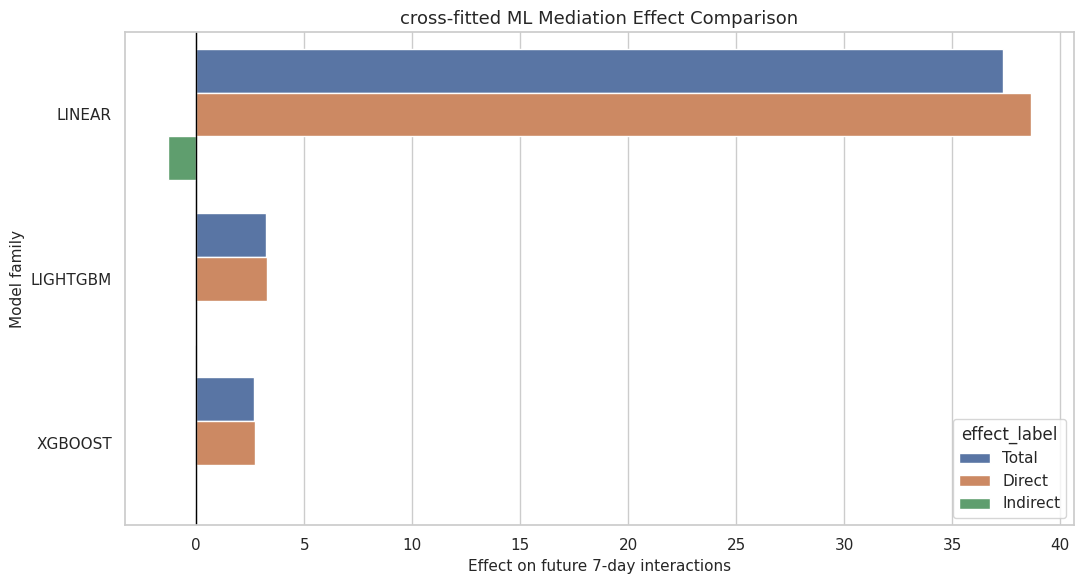

In [11]:
primary_ml_plot = ml_effects.query("outcome == @PRIMARY_OUTCOME").melt(
    id_vars=["model_family"],
    value_vars=["gcomp_total_effect", "natural_direct_effect", "natural_indirect_effect"],
    var_name="effect_type",
    value_name="estimate",
)
primary_ml_plot["effect_label"] = primary_ml_plot["effect_type"].map(
    {
        "gcomp_total_effect": "Total",
        "natural_direct_effect": "Direct",
        "natural_indirect_effect": "Indirect",
    }
)
primary_ml_plot["model_label"] = primary_ml_plot["model_family"].str.upper()

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=primary_ml_plot, x="estimate", y="model_label", hue="effect_label", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("cross-fitted ML Mediation Effect Comparison")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("Model family")
plt.tight_layout()
plt.show()


This comparison is the main advanced-model result. Agreement across Linear, LightGBM, and XGBoost is more reassuring than any one model alone. This matters because the causal estimate is built from these supporting predictions, so weak nuisance behavior should make the downstream effect estimate less persuasive.


#### 12. Compare Predictive Performance

This cell compares out-of-fold predictive performance for the mediator and outcome nuisance models. Stronger prediction alone is insufficient for a better causal estimate. Very weak prediction can make counterfactual estimates unstable.

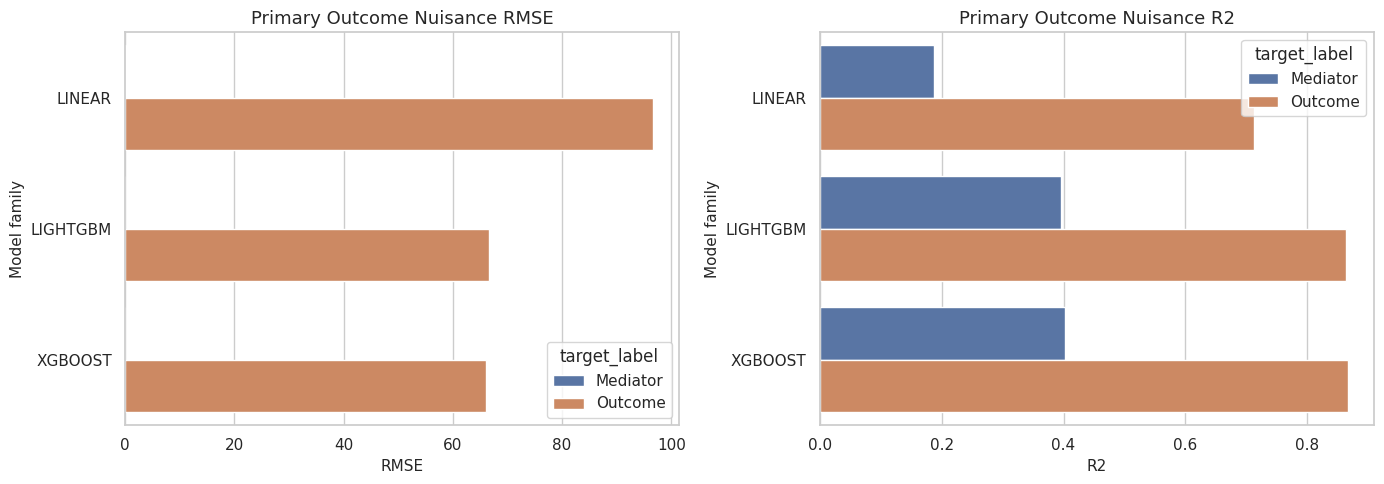

,model_family,outcome,target,rmse,mae,r2
0,linear,Y_future_interactions,mediator,0.1015,0.0703,0.1878
1,linear,Y_future_interactions,outcome,96.6374,71.1050,0.7129
2,lightgbm,Y_future_interactions,mediator,0.0875,0.0629,0.3959
3,lightgbm,Y_future_interactions,outcome,66.7067,47.0941,0.8632
4,xgboost,Y_future_interactions,mediator,0.0870,0.0625,0.4026
5,xgboost,Y_future_interactions,outcome,66.0357,46.7289,0.8659
6,linear,Y_future_play_hours,mediator,0.1015,0.0703,0.1878
7,linear,Y_future_play_hours,outcome,0.3609,0.2428,0.4056
8,lightgbm,Y_future_play_hours,mediator,0.0875,0.0629,0.3959
9,lightgbm,Y_future_play_hours,outcome,0.2388,0.1672,0.7398


In [12]:
performance_plot = ml_performance.copy()
performance_plot["model_label"] = performance_plot["model_family"].str.upper()
performance_plot["target_label"] = performance_plot["target"].str.title()
performance_plot["outcome_label"] = performance_plot["outcome"].map(
    {PRIMARY_OUTCOME: "Future interactions", SECONDARY_OUTCOME: "Future play hours"}
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ["rmse", "r2"]):
    sns.barplot(
        data=performance_plot.query("outcome == @PRIMARY_OUTCOME"),
        x=metric,
        y="model_label",
        hue="target_label",
        ax=ax,
    )
    ax.set_title(f"Primary Outcome Nuisance {metric.upper()}")
    ax.set_xlabel(metric.upper())
    ax.set_ylabel("Model family")
plt.tight_layout()
plt.show()

display(ml_performance.round(4))


The performance table helps explain model behavior. If a flexible model changes the effect estimate but lacks held-out performance improvement, that change deserves caution. This matters because the causal estimate is built from these supporting predictions, so weak nuisance behavior should make the downstream effect estimate less persuasive.


### Heterogeneity from Cross-Fitted Effects

This cell uses LightGBM's row-level cross-fitted effects to summarize heterogeneity. The groups are based on pre-treatment information: prior activity, prior satisfaction, prior discovery, and user activity degree.

In [13]:
# Heterogeneity from cross-fitted effects.
heterogeneity_base = analysis_panel[[
    "user_id",
    "event_date",
    "prior_3day_interactions",
    "prior_3day_high_satisfaction_share",
    "prior_3day_discovery_candidate_share",
    "user_active_degree",
]].copy()

heterogeneity_base["prior_activity_group"] = pd.qcut(
    heterogeneity_base["prior_3day_interactions"].rank(method="first"),
    q=3,
    labels=["low prior activity", "medium prior activity", "high prior activity"],
)
heterogeneity_base["prior_satisfaction_group"] = pd.qcut(
    heterogeneity_base["prior_3day_high_satisfaction_share"].rank(method="first"),
    q=3,
    labels=["low prior satisfaction", "medium prior satisfaction", "high prior satisfaction"],
)
heterogeneity_base["prior_discovery_group"] = pd.qcut(
    heterogeneity_base["prior_3day_discovery_candidate_share"].rank(method="first"),
    q=3,
    labels=["low prior discovery", "medium prior discovery", "high prior discovery"],
)

lightgbm_row_effects = row_level_effects.query(
    "model_family == 'lightgbm' and outcome == @PRIMARY_OUTCOME"
).merge(
    heterogeneity_base,
    on=["user_id", "event_date"],
    how="left",
)

heterogeneity_rows = []
for segment_col in ["prior_activity_group", "prior_satisfaction_group", "prior_discovery_group", "user_active_degree"]:
    summary = (
        lightgbm_row_effects.groupby(segment_col, observed=True)
        .agg(
            user_days=("user_id", "size"),
            users=("user_id", "nunique"),
            total_effect=("ite_total", "mean"),
            direct_effect=("ite_direct", "mean"),
            indirect_effect=("ite_indirect", "mean"),
            mediator_shift=("m1_hat", "mean"),
        )
        .reset_index()
        .rename(columns={segment_col: "segment_value"})
    )
    summary["segment"] = segment_col
    heterogeneity_rows.append(summary)

heterogeneity_effects = pd.concat(heterogeneity_rows, ignore_index=True)
# Convert mediator_shift from average M1 to the segment-level treatment-induced shift.
for segment_col in ["prior_activity_group", "prior_satisfaction_group", "prior_discovery_group", "user_active_degree"]:
    mask = heterogeneity_effects["segment"].eq(segment_col)
    segment_shift = (
        lightgbm_row_effects.groupby(segment_col, observed=True)
        .apply(lambda g: (g["m1_hat"] - g["m0_hat"]).mean(), include_groups=False)
        .reset_index(name="true_mediator_shift")
        .rename(columns={segment_col: "segment_value"})
    )
    heterogeneity_effects.loc[mask, "mediator_shift"] = heterogeneity_effects.loc[mask].merge(
        segment_shift, on="segment_value", how="left"
    )["true_mediator_shift"].to_numpy()

display(heterogeneity_effects.round(4))


,segment_value,user_days,users,total_effect,direct_effect,indirect_effect,mediator_shift,segment
0,low prior activity,2733,133,2.1266,2.3286,-0.2021,0.0195,prior_activity_group
1,medium prior activity,2733,133,3.9690,4.0530,-0.0841,0.0177,prior_activity_group
2,high prior activity,2733,133,3.5253,3.4140,0.1112,0.0180,prior_activity_group
3,low prior satisfaction,2733,133,2.9903,2.8696,0.1208,0.0165,prior_satisfaction_group
4,medium prior satisfaction,2733,130,3.5907,3.7333,-0.1426,0.0158,prior_satisfaction_group
5,high prior satisfaction,2733,113,3.0398,3.1928,-0.1530,0.0229,prior_satisfaction_group
6,low prior discovery,2733,133,2.0592,2.1656,-0.1064,0.0184,prior_discovery_group
7,medium prior discovery,2733,133,3.3925,3.3729,0.0196,0.0166,prior_discovery_group
8,high prior discovery,2733,133,4.1691,4.2572,-0.0881,0.0201,prior_discovery_group
9,UNKNOWN,184,3,4.4181,4.5911,-0.1731,0.0241,user_active_degree


The heterogeneity table asks where the discovery effect is largest. Because these are subgroup summaries of cross-fitted predictions, they are descriptive signals for product targeting.

#### 14. Plot Heterogeneous Effects

This cell plots LightGBM total effects by segment. It focuses on total effects because those are the most stable quantities in the earlier robustness checks.

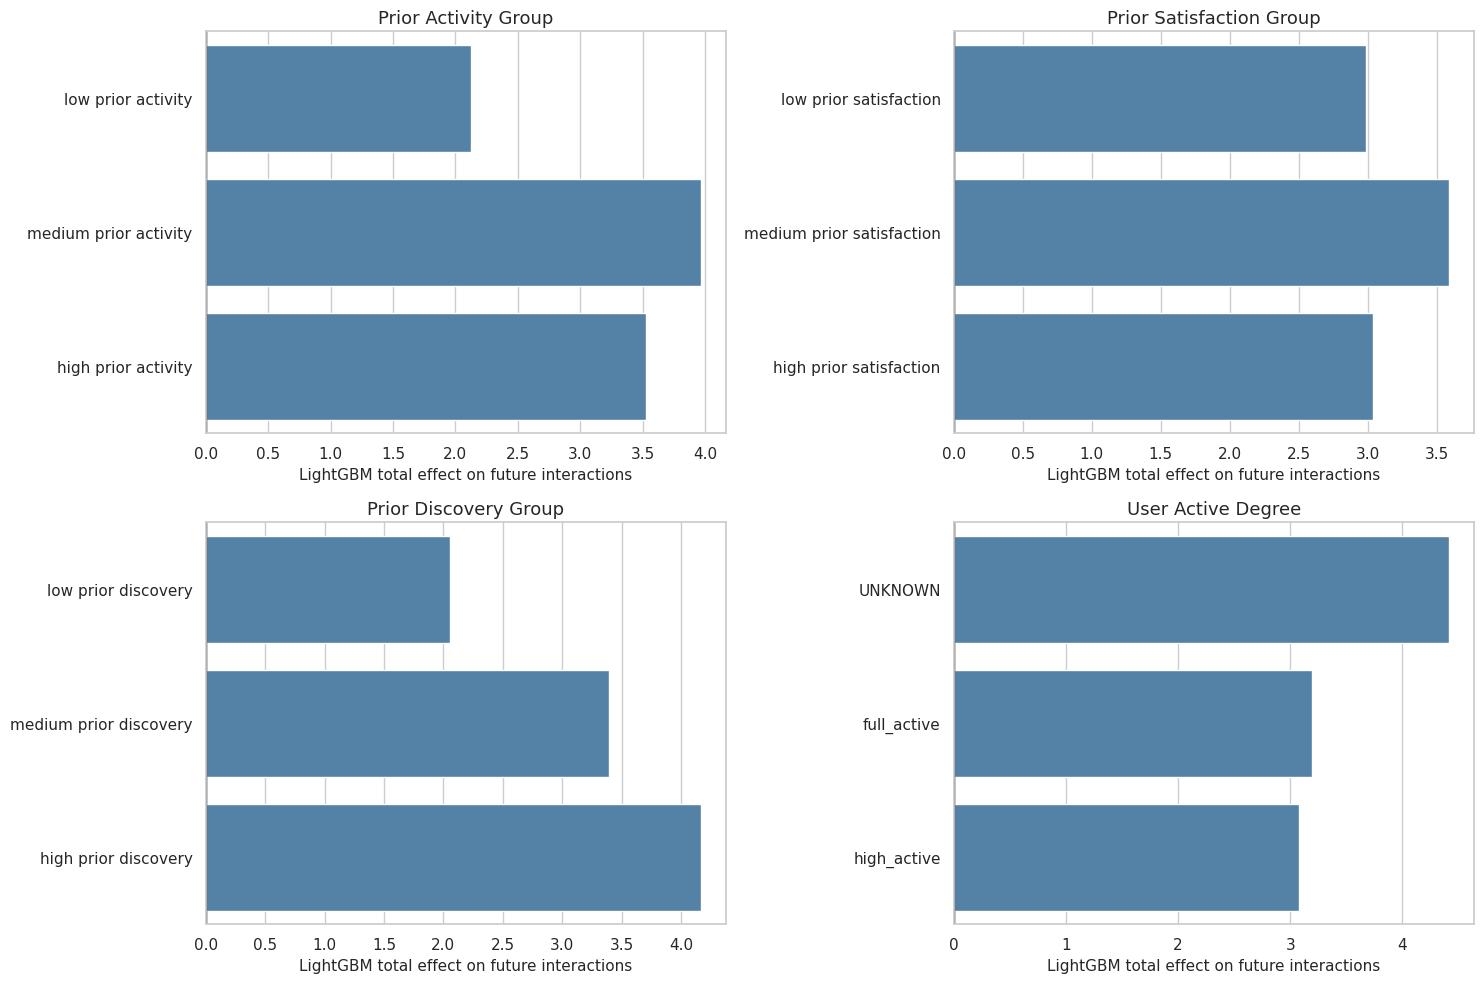

In [14]:
heterogeneity_plot = heterogeneity_effects.copy()
heterogeneity_plot["segment_label"] = heterogeneity_plot["segment"].str.replace("_", " ").str.title()
heterogeneity_plot["segment_value"] = heterogeneity_plot["segment_value"].astype(str)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for ax, segment in zip(axes, heterogeneity_plot["segment"].unique()):
    current = heterogeneity_plot.query("segment == @segment").copy()
    sns.barplot(data=current, x="total_effect", y="segment_value", color="steelblue", ax=ax)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(segment.replace("_", " ").title())
    ax.set_xlabel("LightGBM total effect on future interactions")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


The heterogeneity plot makes the advanced notebook more product-relevant. It shows where the model expects discovery exposure to matter more or less. The teaching point is that weighting can reduce bias while also reducing usable information, so stability matters as much as the point estimate.


### Feature Importance for Mediated Effects

This cell trains full-sample LightGBM and XGBoost nuisance models for feature importance only. These models support interpretation after the cross-fitted effect estimates above. The goal here is model auditability.

In [15]:
# Train full tree models for feature importance.
feature_importance_rows = []
full_design_m = treatment_design(X_covariates, A)
full_design_y = outcome_design(X_covariates, A, M)

importance_model_specs = [
    ("lightgbm", LGBMRegressor(
        n_estimators=120,
        learning_rate=0.05,
        num_leaves=24,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=RANDOM_SEED,
        n_jobs=1,
        verbose=-1,
    )),
    ("xgboost", XGBRegressor(
        n_estimators=120,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_SEED,
        n_jobs=1,
        verbosity=0,
    )),
]

for model_family, model in importance_model_specs:
    mediator_model = clone(model)
    outcome_model = clone(model)
    fit_with_optional_weight(mediator_model, full_design_m, M, sample_weight=weights)
    fit_with_optional_weight(outcome_model, full_design_y, Y, sample_weight=weights)

    for target_name, fitted_model, design in [
        ("mediator", mediator_model, full_design_m),
        ("outcome", outcome_model, full_design_y),
    ]:
        importances = getattr(fitted_model, "feature_importances_", None)
        if importances is None:
            continue
        current = pd.DataFrame(
            {
                "model_family": model_family,
                "target": target_name,
                "feature": design.columns,
                "importance": importances,
            }
        )
        current["importance_share"] = current["importance"] / current["importance"].sum()
        feature_importance_rows.append(current)

feature_importance = pd.concat(feature_importance_rows, ignore_index=True)
top_feature_importance = (
    feature_importance.sort_values(["model_family", "target", "importance"], ascending=[True, True, False])
    .groupby(["model_family", "target"], group_keys=False)
    .head(12)
    .reset_index(drop=True)
)

display(top_feature_importance.round(4))


,model_family,target,feature,importance,importance_share
0,lightgbm,mediator,calendar_day_index,297.0000,0.1076
1,lightgbm,mediator,prior_3day_high_satisfaction_share,260.0000,0.0942
2,lightgbm,mediator,lag_1_high_satisfaction_share,249.0000,0.0902
3,lightgbm,mediator,prior_3day_discovery_candidate_share,187.0000,0.0678
4,lightgbm,mediator,onehot_feat8,147.0000,0.0533
5,lightgbm,mediator,lag_1_valid_play_share,137.0000,0.0496
6,lightgbm,mediator,prior_3day_valid_play_share,122.0000,0.0442
7,lightgbm,mediator,onehot_feat3,118.0000,0.0428
8,lightgbm,mediator,register_days,111.0000,0.0402
9,lightgbm,mediator,prior_3day_total_play_duration_sec,108.0000,0.0391


The feature-importance audit helps reveal whether models are mostly using treatment, mediator, calendar time, prior activity, or profile signals. That matters because an advanced model can look impressive while leaning heavily on confounding proxies.

#### 16. Plot Feature Importance

This cell plots the top features for the LightGBM nuisance models. LightGBM is used here because its importances are usually stable and easy to read.

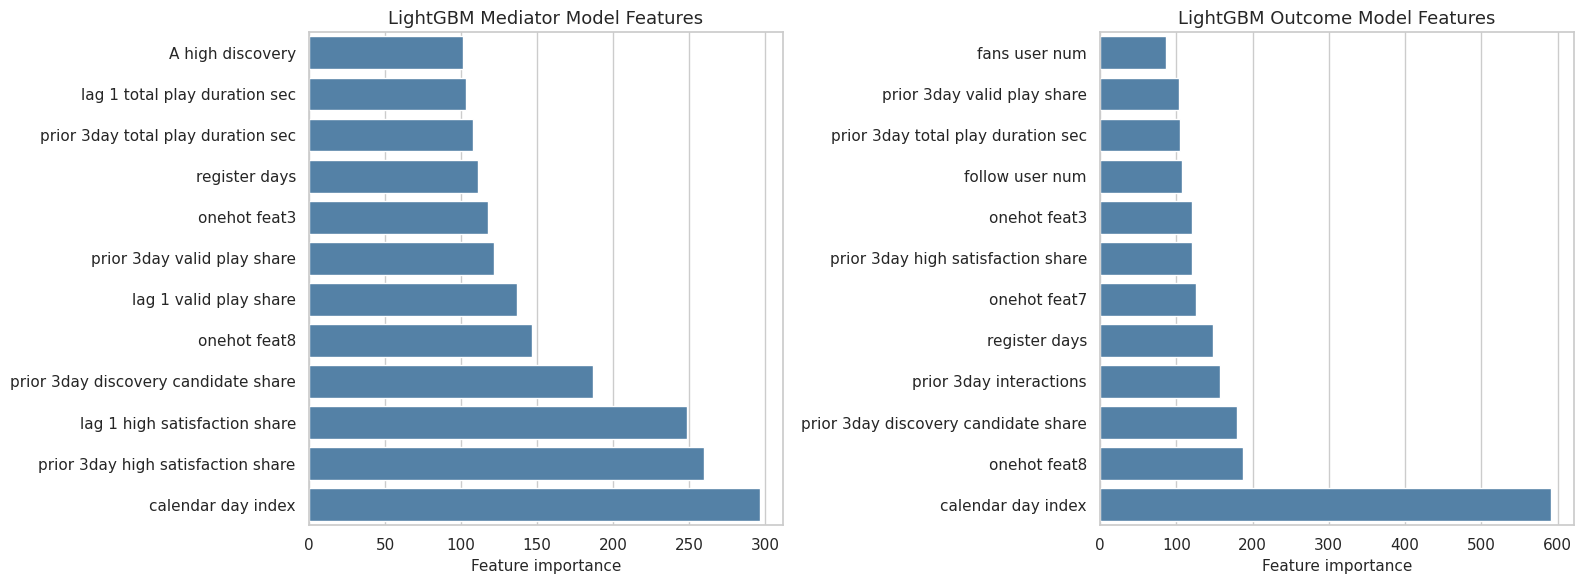

In [16]:
importance_plot = top_feature_importance.query("model_family == 'lightgbm'").copy()
importance_plot["feature_label"] = importance_plot["feature"].str.replace("_", " ").str.slice(0, 45)
importance_plot["target_label"] = importance_plot["target"].str.title()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, target in zip(axes, ["mediator", "outcome"]):
    current = importance_plot.query("target == @target").sort_values("importance", ascending=True)
    sns.barplot(data=current, x="importance", y="feature_label", color="steelblue", ax=ax)
    ax.set_title(f"LightGBM {target.title()} Model Features")
    ax.set_xlabel("Feature importance")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()


The feature plot is an audit layer for model behavior. It tells us what the prediction functions used, which is useful for debugging and for communicating model behavior.

### Advanced Model Summary

This cell combines the linear g-computation result from notebook 04, SEM-style paths, and cross-fitted ML estimates into one comparison table. The table is the main evidence bridge between the simple and advanced estimators.

In [17]:
# Advanced model summary.
linear_reference = effect_summary.query(
    "outcome == @PRIMARY_OUTCOME and estimand in ['gcomp_total_effect', 'natural_direct_effect', 'natural_indirect_effect']"
).pivot_table(index="outcome", columns="estimand", values="estimate").reset_index()
linear_reference["model_family"] = "linear_reference_from_notebook_04"
linear_reference = linear_reference.rename(
    columns={
        "gcomp_total_effect": "total_effect",
        "natural_direct_effect": "direct_effect",
        "natural_indirect_effect": "indirect_effect",
    }
)[["model_family", "total_effect", "direct_effect", "indirect_effect"]]

sem_reference = pd.DataFrame(
    [
        {
            "model_family": "sem_style_path_model",
            "total_effect": sem_path_results.loc[0, "total_path_c_prime_plus_indirect"],
            "direct_effect": sem_path_results.loc[0, "c_prime_A_to_Y"],
            "indirect_effect": sem_path_results.loc[0, "indirect_alpha_beta"],
        }
    ]
)

ml_reference = ml_effects.query("outcome == @PRIMARY_OUTCOME").rename(
    columns={
        "gcomp_total_effect": "total_effect",
        "natural_direct_effect": "direct_effect",
        "natural_indirect_effect": "indirect_effect",
    }
)[["model_family", "total_effect", "direct_effect", "indirect_effect", "mediator_shift", "relative_total_effect"]]

advanced_model_summary = pd.concat(
    [linear_reference, sem_reference, ml_reference],
    ignore_index=True,
    sort=False,
)
advanced_model_summary["indirect_to_total_ratio"] = (
    advanced_model_summary["indirect_effect"] / advanced_model_summary["total_effect"].replace(0, np.nan)
)
advanced_model_summary["total_effect_positive"] = advanced_model_summary["total_effect"] > 0
advanced_model_summary["indirect_effect_small_abs_lt_5"] = advanced_model_summary["indirect_effect"].abs() < 5

display(advanced_model_summary.round(4))


,model_family,total_effect,direct_effect,indirect_effect,mediator_shift,relative_total_effect,indirect_to_total_ratio,total_effect_positive,indirect_effect_small_abs_lt_5
0,linear_reference_from_notebook_04,37.2781,38.5858,-1.3077,NaN,NaN,-0.0351,True,True
1,sem_style_path_model,37.3139,38.4311,-1.1172,NaN,NaN,-0.0299,True,True
2,linear,37.3421,38.6464,-1.3043,0.0231,0.1156,-0.0349,True,True
3,lightgbm,3.2069,3.2652,-0.0583,0.0184,0.0095,-0.0182,True,True
4,xgboost,2.6829,2.7279,-0.0450,0.0138,0.0079,-0.0168,True,True


The comparison table answers the advanced-model question directly. If the total effect is positive across model families and the indirect effect remains small, the notebook 04 result is strengthened.

#### 18. Plot Advanced Model Summary

This cell plots total, direct, and indirect effects across the reference, SEM-style, and cross-fitted ML approaches.

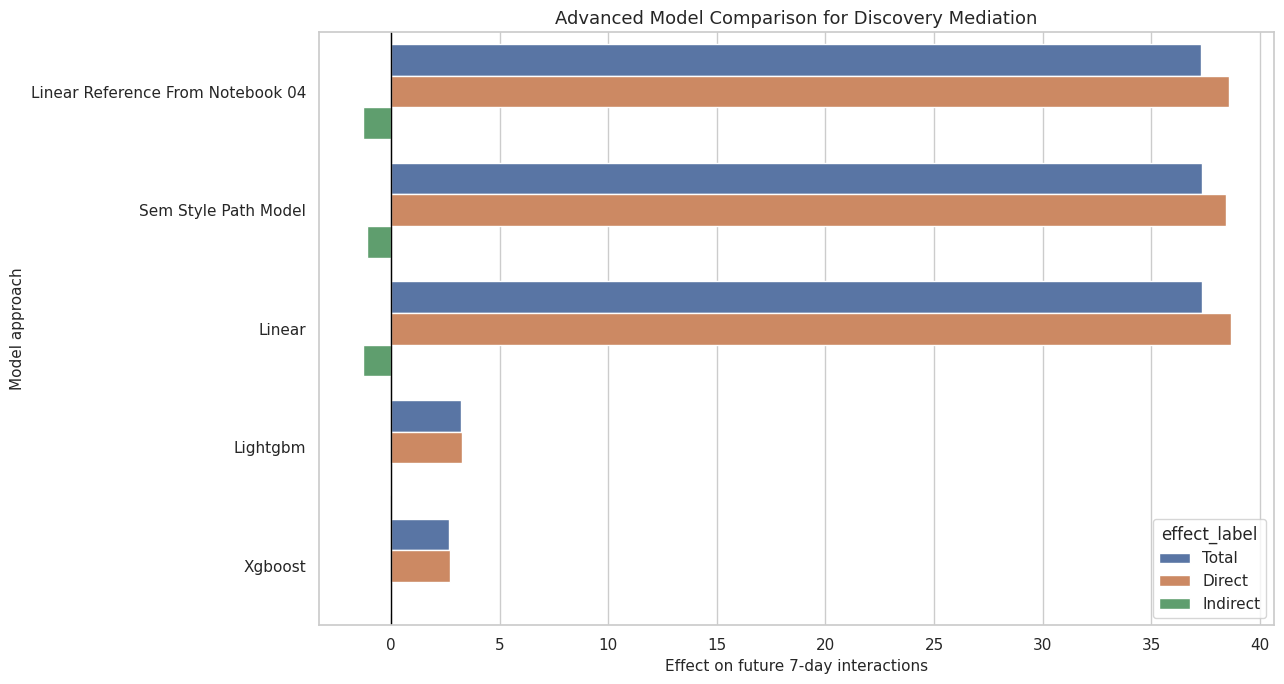

In [18]:
summary_plot = advanced_model_summary.melt(
    id_vars=["model_family"],
    value_vars=["total_effect", "direct_effect", "indirect_effect"],
    var_name="effect_type",
    value_name="estimate",
)
summary_plot["effect_label"] = summary_plot["effect_type"].map(
    {
        "total_effect": "Total",
        "direct_effect": "Direct",
        "indirect_effect": "Indirect",
    }
)
summary_plot["model_label"] = summary_plot["model_family"].str.replace("_", " ").str.title()

fig, ax = plt.subplots(figsize=(13, 7))
sns.barplot(data=summary_plot, x="estimate", y="model_label", hue="effect_label", ax=ax)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Advanced Model Comparison for Discovery Mediation")
ax.set_xlabel("Effect on future 7-day interactions")
ax.set_ylabel("Model approach")
plt.tight_layout()
plt.show()


This final figure is the high-level advanced-model takeaway. It lets a reader see whether the main story depends on the modeling approach. The decomposition is useful only if the pathway labels are kept clear, since direct, indirect, and total effects answer different operational questions.


In [ ]:
#| include: false
# Save advanced model artifacts.
sem_path_summary.to_csv(SEM_PATH_OUTPUT, index=False)
sem_bootstrap.to_csv(SEM_BOOTSTRAP_OUTPUT, index=False)
ml_effects.to_csv(ML_EFFECTS_OUTPUT, index=False)
ml_performance.to_csv(ML_PERFORMANCE_OUTPUT, index=False)
heterogeneity_effects.to_csv(HETEROGENEITY_OUTPUT, index=False)
feature_importance.to_csv(FEATURE_IMPORTANCE_OUTPUT, index=False)
advanced_model_summary.to_csv(ADVANCED_SUMMARY_OUTPUT, index=False)


The key comparison is between the simple mediation estimates, SEM-style paths, and cross-fitted ML estimates. This keeps the interpretation focused on whether the mediation story survives more flexible modeling choices.


### Takeaways and Next Step

This notebook added advanced model checks to the discovery-quality mediation workflow:

- SEM-style path modeling gives a compact path-coefficient version of the mediation story.
- Cross-fitted Linear, LightGBM, and XGBoost nuisance models test whether the decomposition survives nonlinear prediction functions.
- Heterogeneity summaries show where discovery exposure appears more or less valuable.
- Feature-importance tables audit which variables the tree-based nuisance models rely on.
- The final comparison table shows whether the main result is stable across modeling approaches.

Together, the simple mediation estimates, robustness checks, and advanced-model comparisons provide the evidence record for the discovery-quality conclusion.